In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import LabelEncoder , StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [5]:
df = pd.read_csv("mnist_train.csv")

In [6]:
df_test = pd.read_csv("mnist_test.csv")

In [7]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df_test.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df.shape

(60000, 785)

In [10]:
df_test.shape

(10000, 785)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [13]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

In [14]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


In [15]:
# preprocess

In [20]:
X_train = df.drop("label" , axis = 1).values
y_train = df["label"].values
X_test = df_test.drop("label" , axis = 1).values
y_test = df_test["label"].values

In [22]:
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0 

In [ ]:
X_train_img = X_train.reshape(-1 , 28,28) # ( block , row , col )
X_test_img = X_test.reshape(-1 , 28,28)

In [24]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [26]:
y_train_cat = to_categorical(y_train ,10)
y_test_cat = to_categorical(y_test , 10  )

In [28]:
perceptron  = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(10 , activation = "softmax")
])

In [29]:
perceptron.compile( optimizer = "sgd" , loss = "categorical_crossentropy" , metrics = ["accuracy"])

In [30]:
his = perceptron.fit(X_train_img , y_train_cat , epochs = 5 , batch_size = 32 , validation_data = (X_test_img , y_test_cat) , verbose =1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8153 - loss: 0.7806 - val_accuracy: 0.8824 - val_loss: 0.4799
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8807 - loss: 0.4560 - val_accuracy: 0.8965 - val_loss: 0.3995
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8920 - loss: 0.4032 - val_accuracy: 0.9026 - val_loss: 0.3665
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8970 - loss: 0.3768 - val_accuracy: 0.9058 - val_loss: 0.3485
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9003 - loss: 0.3600 - val_accuracy: 0.9079 - val_loss: 0.3353


In [33]:
acc = perceptron.evaluate(X_test_img , y_test_cat , verbose = 0)[1]

In [34]:
acc

0.9078999757766724

In [35]:
#ANN

In [36]:
a = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128 , activation = 'relu'),
    Dense(64 , activation = "relu"),
    Dense(10 , activation = "softmax")
])

In [40]:
a.compile(optimizer = "adam" , loss = "categorical_crossentropy" , metrics = ["accuracy"])

In [41]:
hist = a.fit(X_train_img , y_train_cat , epochs = 10 , batch_size = 64 , validation_data =  (X_test_img , y_test_cat) , verbose = 1)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9224 - loss: 0.2677 - val_accuracy: 0.9610 - val_loss: 0.1323
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9671 - loss: 0.1104 - val_accuracy: 0.9705 - val_loss: 0.0941
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9766 - loss: 0.0762 - val_accuracy: 0.9745 - val_loss: 0.0833
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9822 - loss: 0.0576 - val_accuracy: 0.9718 - val_loss: 0.0898
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9863 - loss: 0.0440 - val_accuracy: 0.9754 - val_loss: 0.0768
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9888 - loss: 0.0359 - val_accuracy: 0.9782 - val_loss: 0.0749
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9906 - loss: 0.0289 - val_accuracy: 0.9792 - val_loss: 0.0754
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9921 - loss: 0.0248 - val_accuracy: 0.

In [77]:
acc_ann = a.evaluate(X_test_img , y_test_cat , verbose = 1)[1]

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [75]:
acc_ann

NameError: name 'acc_ann' is not defined

In [51]:
X_train_cnn = X_train.reshape(-1 , 28,28 ,1) # ( block , row , col ,no_layer/channel)
X_test_cnn = X_test.reshape(-1 , 28,28 ,1)
# grey_scale==> 1 = no_of channel , rgb ==> 3 no_of channel

In [48]:
cnn = Sequential ([
    Conv2D(32, kernel_size = (3,3) , activation = "relu" , input_shape = (28,28,1)),
    MaxPooling2D( pool_size = (2,2)),
    Conv2D(64 ,kernel_size = (3,3) , activation="relu"),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),
    Dense(128 , activation = "relu"),
    Dropout(0.5),
    Dense(10 ,activation = "softmax")
])

In [49]:
#kernel_size = filter 

In [50]:
cnn.compile(optimizer = "adam" , loss = "categorical_crossentropy" , metrics = ["accuracy"])

In [52]:
history = cnn.fit(X_train_cnn , y_train_cat , epochs = 10 , batch_size = 64 , validation_data =  (X_test_img , y_test_cat) , verbose = 1)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9216 - loss: 0.2552 - val_accuracy: 0.9822 - val_loss: 0.0555
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9740 - loss: 0.0891 - val_accuracy: 0.9859 - val_loss: 0.0427
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9808 - loss: 0.0662 - val_accuracy: 0.9873 - val_loss: 0.0350
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9841 - loss: 0.0525 - val_accuracy: 0.9898 - val_loss: 0.0312
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9861 - loss: 0.0456 - val_accuracy: 0.9903 - val_loss: 0.0274
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9879 - loss: 0.0392 - val_accuracy: 0.9909 - val_loss: 0.0273
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9894 - loss: 0.0342 - val_accuracy: 0.9917 - val_loss: 0.0245
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9908 - loss: 0.0306 - 

In [72]:
acc_cnn = cnn.evaluate(X_test_cnn , y_test_cat , verbose = 1)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9926 - loss: 0.0270


In [73]:
acc_cnn

0.9926000237464905

In [ ]:
import matplotlib.pyplot as plt

def plot_training(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{title} Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{title} Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

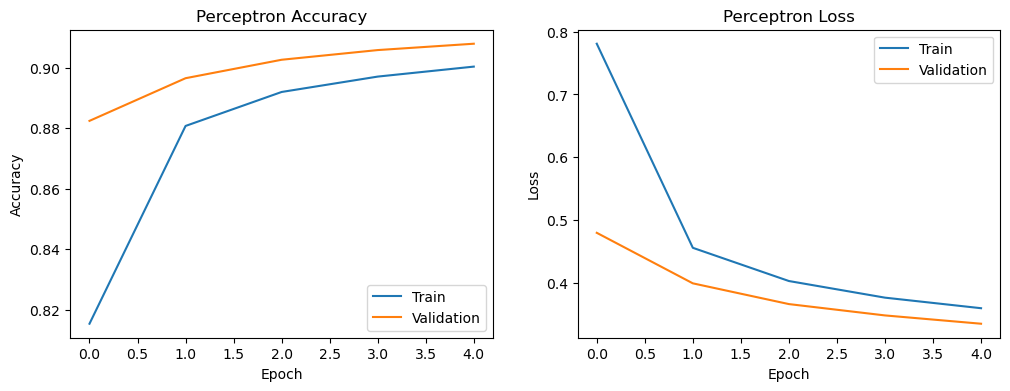

In [57]:
plot_training(his , "Perceptron")

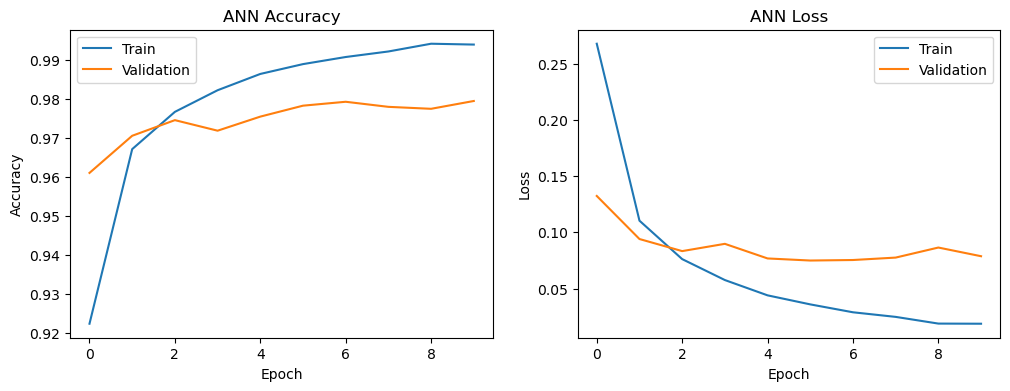

In [58]:
plot_training(hist , "ANN")

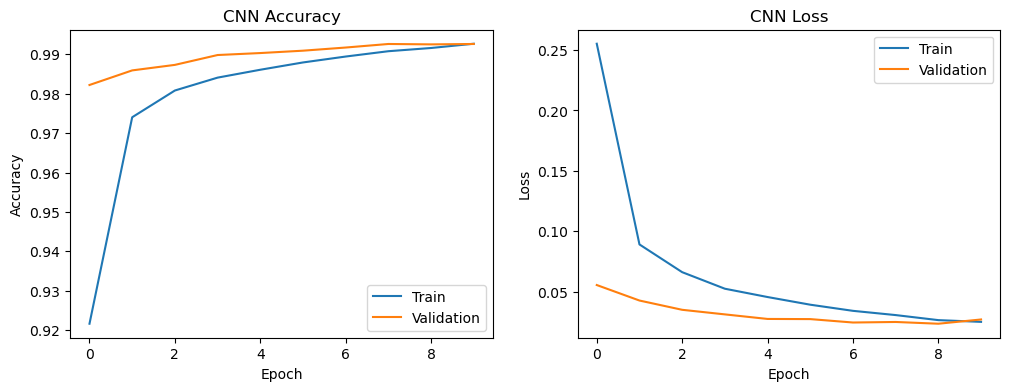

In [59]:
plot_training(history , "CNN")

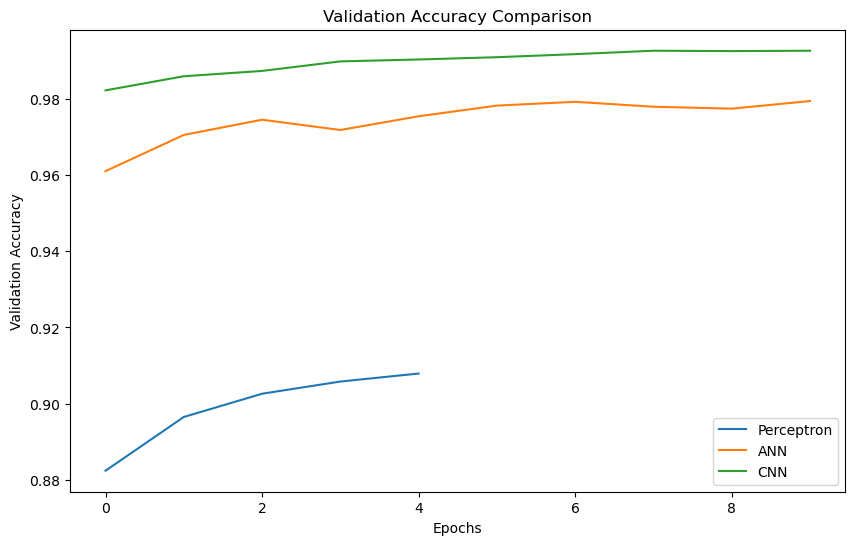

In [62]:
plt.figure(figsize=(10,6))

plt.plot(his.history['val_accuracy'], label='Perceptron')
plt.plot(hist.history['val_accuracy'], label='ANN')
plt.plot(history.history['val_accuracy'], label='CNN')   # agar tumhara variable hist hai

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

In [63]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)

    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(idxs):

        # Original Image
        plt.subplot(2, n, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")

        # Predictions from all models
        preds = [
            np.argmax(
                model.predict(
                    X_cnn[idx].reshape(1, 28, 28, 1)
                    if name == "CNN"
                    else X[idx].reshape(1, 28, 28),
                    verbose=0
                )
            )
            for model, name in zip(models, model_names)
        ]

        plt.subplot(2, n, n + i + 1)
        plt.axis("off")
        plt.title(
            "\n".join(
                f"{name}: {pred}"
                for name, pred in zip(model_names, preds)
            )
        )

    plt.tight_layout()
    plt.show()

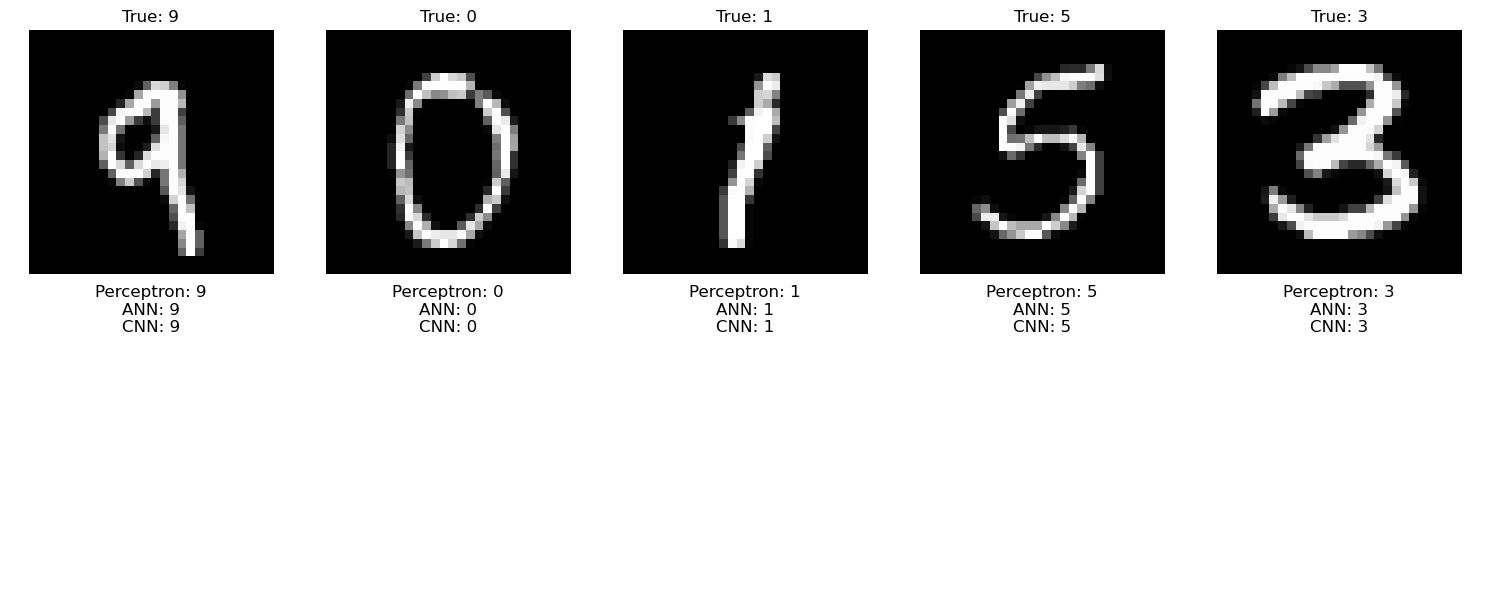

In [65]:
show_side_by_side([perceptron , a ,cnn] , ["Perceptron" ,"ANN" ,"CNN"], X_test_img , X_test_cnn , y_test , 5)

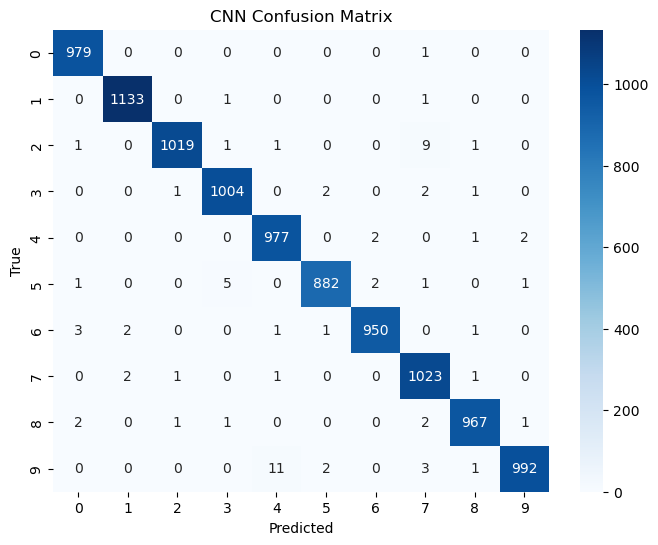

In [67]:
# CNN Predictions
y_pred_cnn = np.argmax(cnn.predict(X_test_img, verbose=0), axis=1)

# True Labels
y_true = np.argmax(y_test_cat, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_cnn)

# Plot Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [70]:
# Final Accuracies (multiply by 100 if they are in decimal)
final_accs = [acc * 100, acc_ann * 100, acc_cnn * 100]

models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))

bars = plt.bar(
    models,
    final_accs,
    color=["#ff9999", "#66b3ff", "#99ff99"]
)

plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")

# Display accuracy values on top of bars
for bar, acc in zip(bars, final_accs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 1,
        f"{acc:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.ylim(80, 100)
plt.show()

NameError: name 'acc_ann' is not defined